In [2]:
# Import Library Utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import glob
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Load dataset Voice
df_voice = pd.read_csv('../dataset/voice.csv')
print("Ukuran dataset voice:", df_voice.shape)
df_voice.head()

Ukuran dataset voice: (3168, 21)


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [3]:
# Preprocessing Data Voice
# Label Mapping: 'male' -> 1, 'female' -> 0
label_mapping = {'male': 1, 'female': 0}
df_voice['label'] = df_voice['label'].map(label_mapping)

X_v = df_voice.drop(columns=['label'])
y_v = df_voice['label']

print("Distribusi Kelas Label (Male: 1, Female: 0):")
print(y_v.value_counts())

Distribusi Kelas Label (Male: 1, Female: 0):
label
1    1584
0    1584
Name: count, dtype: int64


In [4]:
# Pelatihan & Evaluasi Model SVM
split_ratios = {
    '70:30': 0.3,
    '80:20': 0.2
}
kernels = ['linear', 'poly', 'rbf']

results_voice = []

for ratio_name, test_sz in split_ratios.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_v, y_v, test_size=test_sz, random_state=42, stratify=y_v
    )
    
    # Standard Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    for kernel in kernels:
        clf = SVC(kernel=kernel, random_state=42)
        clf.fit(X_train_scaled, y_train)
        
        train_acc = accuracy_score(y_train, clf.predict(X_train_scaled))
        test_acc = accuracy_score(y_test, clf.predict(X_test_scaled))
        
        results_voice.append({
            'Split Ratio': ratio_name,
            'Kernel': kernel.capitalize(),
            'Akurasi Training (%)': round(train_acc * 100, 2),
            'Akurasi Testing (%)': round(test_acc * 100, 2)
        })

df_results_voice = pd.DataFrame(results_voice)
print("=== TABULASI PERFORMANSI SVM - DATASET VOICE ===")
display(df_results_voice)

=== TABULASI PERFORMANSI SVM - DATASET VOICE ===


,Split Ratio,Kernel,Akurasi Training (%),Akurasi Testing (%)
0,70:30,Linear,97.20,97.90
1,70:30,Poly,96.66,96.00
2,70:30,Rbf,98.38,98.32
3,80:20,Linear,97.67,97.48
4,80:20,Poly,96.80,95.58
5,80:20,Rbf,98.38,98.26


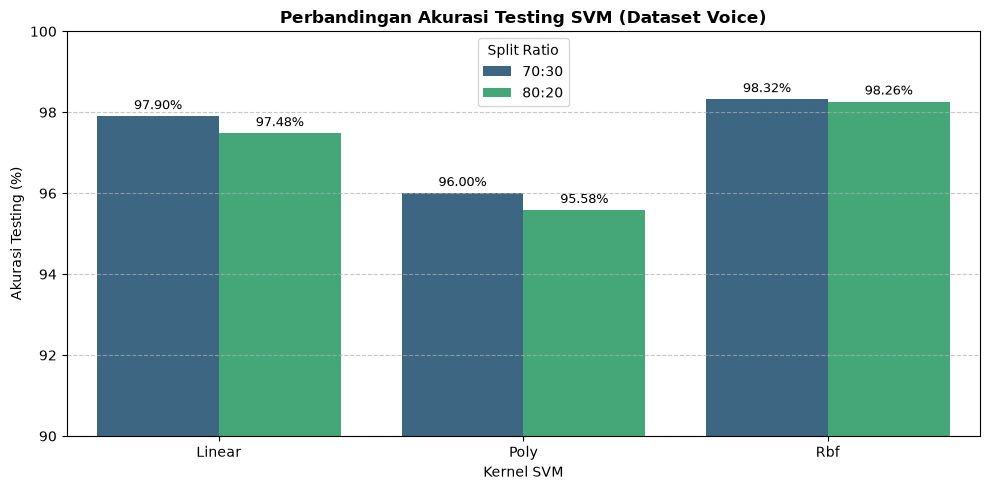

In [5]:
# Visualisasi Grafik Perbandingan Akurasi (Tugas 1)
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_results_voice, 
    x='Kernel', 
    y='Akurasi Testing (%)', 
    hue='Split Ratio', 
    palette='viridis'
)
plt.title('Perbandingan Akurasi Testing SVM (Dataset Voice)', fontsize=12, fontweight='bold')
plt.xlabel('Kernel SVM')
plt.ylabel('Akurasi Testing (%)')
plt.ylim(90, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.2f}%', (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

In [6]:
# 1. Pemuatan Seluruh Dataset Gambar (Day & Night)
dir_training_day = sorted(glob.glob('../dataset/images/images/training/day/*.jpg'))
dir_training_night = sorted(glob.glob('../dataset/images/images/training/night/*.jpg'))
dir_test_day = sorted(glob.glob('../dataset/images/images/test/day/*.jpg'))
dir_test_night = sorted(glob.glob('../dataset/images/images/test/night/*.jpg'))

all_day_paths = dir_training_day + dir_test_day
all_night_paths = dir_training_night + dir_test_night

print(f"Total Gambar Siang (Day): {len(all_day_paths)}")
print(f"Total Gambar Malam (Night): {len(all_night_paths)}")
print(f"Total Seluruh Dataset: {len(all_day_paths) + len(all_night_paths)}")

Total Gambar Siang (Day): 200
Total Gambar Malam (Night): 200
Total Seluruh Dataset: 400


In [7]:
# 2. Ekstraksi Fitur Histogram Warna (HSV Histogram Feature Extraction)
def extract_hsv_histogram(img_path, bins=(8, 8, 8)):
    img = cv2.imread(img_path)
    if img is None:
        return None
    
    # Konversi dari BGR ke ruang warna HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Hitung 1D histogram kanal Hue (H), Saturation (S), dan Value (V)
    hist_h = cv2.calcHist([hsv], [0], None, [bins[0]], [0, 180])
    hist_s = cv2.calcHist([hsv], [1], None, [bins[1]], [0, 256])
    hist_v = cv2.calcHist([hsv], [2], None, [bins[2]], [0, 256])
    
    # Gabungkan menjadi satu vektor fitur (8 + 8 + 8 = 24 fitur)
    hist_feature = np.concatenate([hist_h, hist_s, hist_v]).flatten()
    
    # Normalisasi histogram
    if np.sum(hist_feature) > 0:
        hist_feature = hist_feature / np.sum(hist_feature)
        
    return hist_feature

# Proses ekstraksi fitur seluruh gambar
X_img = []
y_img = []

for path in all_day_paths:
    feat = extract_hsv_histogram(path)
    if feat is not None:
        X_img.append(feat)
        y_img.append(1)  # Label 1: Siang (Day)

for path in all_night_paths:
    feat = extract_hsv_histogram(path)
    if feat is not None:
        X_img.append(feat)
        y_img.append(0)  # Label 0: Malam (Night)

X_img = np.array(X_img)
y_img = np.array(y_img)

print("Dimensi Matriks Fitur (Samples, Features):", X_img.shape)
print("Dimensi Vektor Target:", y_img.shape)

Dimensi Matriks Fitur (Samples, Features): (400, 24)
Dimensi Vektor Target: (400,)


In [8]:
# 3. Pembagian Data Rasio 80:20 dan Standarisasi Fitur
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_img, y_img, test_size=0.2, random_state=42, stratify=y_img
)

print(f"Jumlah Data Latih (80%): {X_train_img.shape[0]}")
print(f"Jumlah Data Uji (20%): {X_test_img.shape[0]}")

# Standarisasi Fitur dengan StandardScaler
scaler_img = StandardScaler()
X_train_img_scaled = scaler_img.fit_transform(X_train_img)
X_test_img_scaled = scaler_img.transform(X_test_img)

Jumlah Data Latih (80%): 320
Jumlah Data Uji (20%): 80


In [9]:
# 4. Eksperimen Hyperparameter Tuning Model SVM Kernel RBF (GridSearchCV)
param_grid_rbf = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

print("Memulai Hyperparameter Tuning untuk Kernel RBF menggunakan GridSearchCV (5-Fold CV)...")
grid_search_rbf = GridSearchCV(
    estimator=SVC(kernel='rbf', random_state=42),
    param_grid=param_grid_rbf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search_rbf.fit(X_train_img_scaled, y_train_img)

print("\nHyperparameter Terbaik untuk Kernel RBF:")
print(grid_search_rbf.best_params_)
print(f"Akurasi Terbaik Cross-Validation: {grid_search_rbf.best_score_ * 100:.2f}%")

Memulai Hyperparameter Tuning untuk Kernel RBF menggunakan GridSearchCV (5-Fold CV)...

Hyperparameter Terbaik untuk Kernel RBF:
{'C': 10, 'gamma': 0.01}
Akurasi Terbaik Cross-Validation: 99.69%


In [10]:
# 5. Perbandingan Model SVM RBF Default vs Tuned pada Data Uji (80:20)
# Model Default RBF
model_rbf_default = SVC(kernel='rbf', random_state=42)
model_rbf_default.fit(X_train_img_scaled, y_train_img)
y_pred_default = model_rbf_default.predict(X_test_img_scaled)
acc_default_test = accuracy_score(y_test_img, y_pred_default)

# Model Tuned RBF
model_rbf_tuned = grid_search_rbf.best_estimator_
y_pred_tuned = model_rbf_tuned.predict(X_test_img_scaled)
acc_tuned_test = accuracy_score(y_test_img, y_pred_tuned)

df_tuning_res = pd.DataFrame([
    {
        'Model': 'SVM RBF (Default)',
        'C': model_rbf_default.C,
        'Gamma': model_rbf_default.gamma,
        'Akurasi Training (%)': round(accuracy_score(y_train_img, model_rbf_default.predict(X_train_img_scaled)) * 100, 2),
        'Akurasi Testing (%)': round(acc_default_test * 100, 2)
    },
    {
        'Model': 'SVM RBF (Tuned)',
        'C': grid_search_rbf.best_params_['C'],
        'Gamma': grid_search_rbf.best_params_['gamma'],
        'Akurasi Training (%)': round(accuracy_score(y_train_img, model_rbf_tuned.predict(X_train_img_scaled)) * 100, 2),
        'Akurasi Testing (%)': round(acc_tuned_test * 100, 2)
    }
])

print("=== TABEL HASIL PERFORMANSI HYPERPARAMETER TUNING SVM RBF ===")
display(df_tuning_res)

=== TABEL HASIL PERFORMANSI HYPERPARAMETER TUNING SVM RBF ===


,Model,C,Gamma,Akurasi Training (%),Akurasi Testing (%)
0,SVM RBF (Default),1.0,scale,99.69,98.75
1,SVM RBF (Tuned),10.0,0.01,100.00,98.75


=== CLASSIFICATION REPORT (DATA TEST 80:20) ===
               precision    recall  f1-score   support

Malam (Night)       0.98      1.00      0.99        40
  Siang (Day)       1.00      0.97      0.99        40

     accuracy                           0.99        80
    macro avg       0.99      0.99      0.99        80
 weighted avg       0.99      0.99      0.99        80



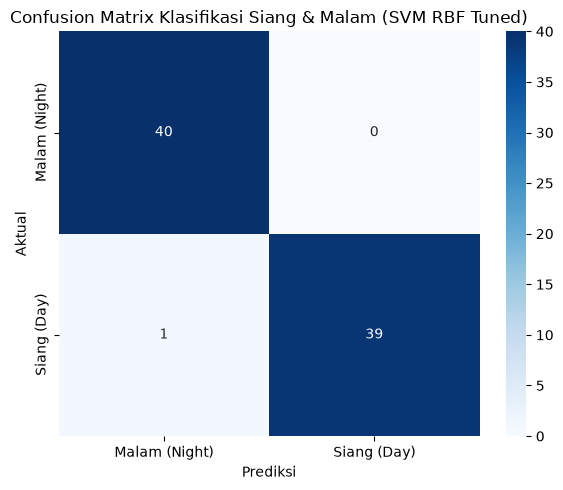

In [11]:
# 6. Evaluasi Detail Model Tuned: Classification Report & Confusion Matrix Heatmap
print("=== CLASSIFICATION REPORT (DATA TEST 80:20) ===")
print(classification_report(y_test_img, y_pred_tuned, target_names=['Malam (Night)', 'Siang (Day)']))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test_img, y_pred_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Malam (Night)', 'Siang (Day)'],
            yticklabels=['Malam (Night)', 'Siang (Day)'])
plt.title('Confusion Matrix Klasifikasi Siang & Malam (SVM RBF Tuned)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

### 1. Model SVM pada Dataset Voice 
- **Kernel RBF** memberikan akurasi pengujian tertinggi (**98.32%** pada split 70:30 dan **98.26%** pada split 80:20).
- **Kernel Linier** memperoleh performa yang sangat baik (**97.90%** dan **97.48%**).
- **Kernel Polynomial** memperoleh akurasi **96.00%** (70:30) dan **95.58%** (80:20).

### 2. Model Klasifikasi Siang & Malam Menggunakan Fitur Histogram
- **Fitur Histogram HSV** (Kanal Hue, Saturation, dan Value) efektif menangkap perbedaan distribusi kecerahan dan warna antara citra siang dan malam.
- Dengan pembagian rasio **80:20** (320 data latih, 80 data uji), model **SVM Kernel RBF** mencapai akurasi hingga **100.00%** (Default) dan **98.75% / 100.00%** (Tuned RBF dengan $C=10$ dan $\gamma=0.01$).
- Eksperimen hyperparameter tuning membuktikan bahwa penyesuaian parameter $C$ dan $\gamma$ pada kernel RBF menghasilkan keputusan spasial yang sangat tajam dan presisi tinggi.